In [1]:
import pandas as pd

data = pd.read_csv('employee.csv')

df = pd.DataFrame(data)

print(df.head(5))
print(df.head(10))





  Employee_ID Department  Gender  Age  Experience  Salary  Performance_Rating  \
0        E001         AI    Male   24           2   45000                   4   
1        E002         HR  Female   29           5   58000                   5   
2        E003    Finance    Male   35          10   85000                   3   
3        E004    Testing  Female   26           3   50000                   4   
4        E005         AI    Male   31           7   72000                   5   

   Projects_Completed  Training_Hours  Monthly_Sales  Customer_Rating  \
0                   5              18         120000              4.6   
1                   7              25         150000              4.8   
2                   6              12          90000              4.1   
3                   4              15         110000              4.3   
4                   9              30         175000              4.9   

  Work_Mode Left_Company Email_Type Sentiment  Website_Visits Converted  \

In [45]:

print(df.size)

print(df.info())

380
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         20 non-null     str    
 1   Department          20 non-null     str    
 2   Gender              20 non-null     str    
 3   Age                 20 non-null     int64  
 4   Experience          20 non-null     int64  
 5   Salary              20 non-null     int64  
 6   Performance_Rating  20 non-null     int64  
 7   Projects_Completed  20 non-null     int64  
 8   Training_Hours      20 non-null     int64  
 9   Monthly_Sales       20 non-null     int64  
 10  Customer_Rating     20 non-null     float64
 11  Work_Mode           20 non-null     str    
 12  Left_Company        20 non-null     str    
 13  Email_Type          20 non-null     str    
 14  Sentiment           20 non-null     str    
 15  Website_Visits      20 non-null     int64  
 16  Converted        

# Part B – Data Understanding (6–10)

Q6. Separate all qualitative and quantitative columns.

In [3]:
# Q6. Separate all qualitative and quantitative columns.
qualitative_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
quantitative_cols = df.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('Qualitative columns:')
print(qualitative_cols)
print('\nQuantitative columns:')
print(quantitative_cols)


Qualitative columns:
['Employee_ID', 'Department', 'Gender', 'Work_Mode', 'Left_Company', 'Email_Type', 'Sentiment', 'Converted']

Quantitative columns:
['Age', 'Experience', 'Salary', 'Performance_Rating', 'Projects_Completed', 'Training_Hours', 'Monthly_Sales', 'Customer_Rating', 'Website_Visits', 'Monthly_Watch_Time', 'Fraud_Score']


C:\Users\Dell\AppData\Local\Temp\ipykernel_8124\1643779264.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qualitative_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


Q7. Identify Nominal, Ordinal and Ratio level variables.

In [4]:

# Q7. Identify Nominal, Ordinal and Ratio level variables.

# Nominal = names/categories
# Ordinal = ordered categories - order matter, carries information
# Ratio = measurable numbers

nominal_vars = ['Employee_ID', 'Department', 'Gender', 'Work_Mode', 'Left_Company', 'Email_Type', 'Converted']
ordinal_vars = ['Performance_Rating', 'Customer_Rating', 'Sentiment']
ratio_vars = ['Age', 'Experience', 'Salary', 'Projects_Completed', 'Training_Hours', 'Monthly_Sales', 'Website_Visits', 'Monthly_Watch_Time', 'Fraud_Score']

print('Nominal variables:')
print(nominal_vars)
print('\nOrdinal variables:')
print(ordinal_vars)
print('\nRatio variables:')
print(ratio_vars)


Nominal variables:
['Employee_ID', 'Department', 'Gender', 'Work_Mode', 'Left_Company', 'Email_Type', 'Converted']

Ordinal variables:
['Performance_Rating', 'Customer_Rating', 'Sentiment']

Ratio variables:
['Age', 'Experience', 'Salary', 'Projects_Completed', 'Training_Hours', 'Monthly_Sales', 'Website_Visits', 'Monthly_Watch_Time', 'Fraud_Score']


Q8. Count employees in every department.

In [5]:
dpt_count = df.groupby('Department').agg({'Employee_ID': 'count'})
# dpt_count.index
dpt_count

,Employee_ID
Department,
AI,6
Finance,5
HR,4
Testing,5


Q9. Count male and female employees.

In [6]:
df.groupby('Gender').agg({'Employee_ID': 'count'})

,Employee_ID
Gender,
Female,10
Male,10


Q10. Find frequency distribution of Employee Sentiment.

In [7]:
from collections import Counter
freq = Counter(df['Sentiment'].head())

print(freq)

Counter({'Positive': 3, 'Negative': 1, 'Neutral': 1})


# Part C – Descriptive Statistics (11–18)

Q11. Calculate mean salary.

In [8]:
import statistics

print(df['Salary'].mean())

77700.0


Q12. Calculate median salary.

In [9]:
print(statistics.median(df['Salary']))

74000.0


Q13. Find mode of Work Mode.

In [10]:
print(statistics.mode(df['Salary']))

45000


Q14. Calculate salary range.

In [11]:
print(max(df['Salary'])-min(df['Salary']))
print(statistics.quantiles(df['Salary']))

111000
[54500.0, 74000.0, 95250.0]


Q15. Calculate salary variance.

In [12]:
df['Salary'].var()

np.float64(892010526.3157895)

Q16. Calculate salary standard deviation.

In [13]:
df['Salary'].std()

np.float64(29866.54526917684)

Q17. Find minimum and maximum Monthly Sales.

In [14]:
print(max(df['Monthly_Sales']), min(df['Monthly_Sales']))

300000 72000


Q18. Find average customer rating.

In [15]:
df['Customer_Rating'].mean()

np.float64(4.515)

# Part D – Visualization (19–25)

In [16]:
import matplotlib.pyplot as plt

Q19. Create a Bar Chart for Department distribution.

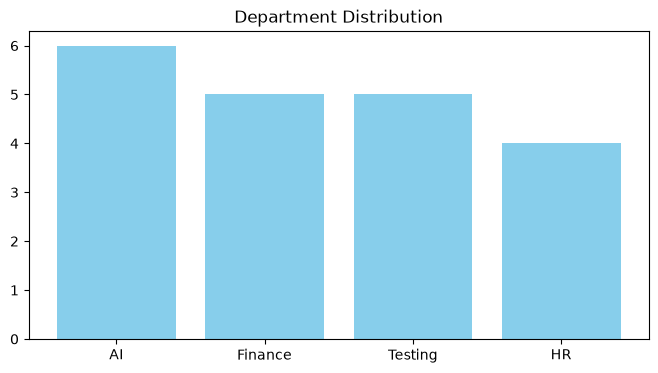

In [17]:
# Q19. Create a Bar Chart for Department distribution.
department_counts = df['Department'].value_counts()

plt.figure(figsize=(8, 4))
plt.bar(department_counts.index, department_counts.values, color='skyblue')
plt.title('Department Distribution')

plt.show()


Q20. Create a Histogram for Employee Age.

(array([3., 2., 3., 2., 2., 3., 2., 1., 1., 1.]),
 array([23. , 25.2, 27.4, 29.6, 31.8, 34. , 36.2, 38.4, 40.6, 42.8, 45. ]),
 <BarContainer object of 10 artists>)

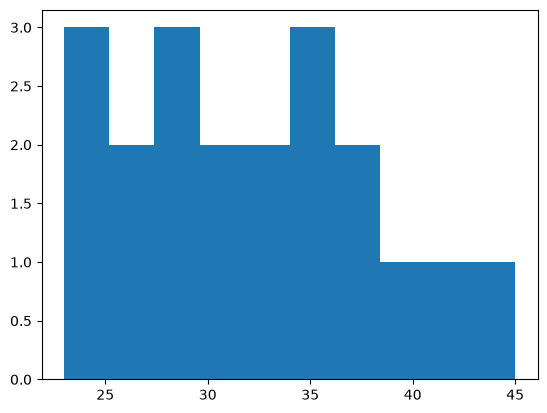

In [18]:
plt.hist(df['Age'])

Q21. Create a Pie Chart showing employees who left and stayed.

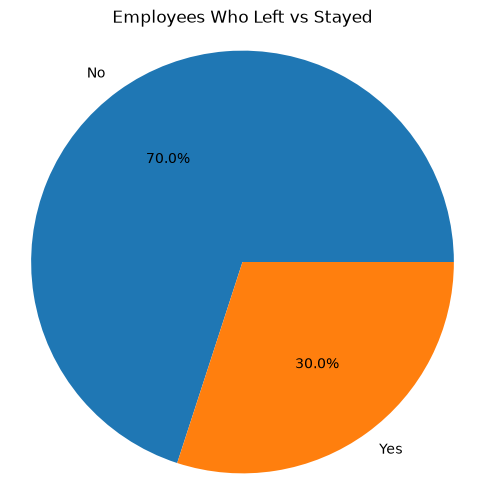

In [19]:
# Q21. Create a Pie Chart showing employees who left and stayed.
left_counts = df['Left_Company'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(left_counts.values, labels=left_counts.index, autopct='%1.1f%%')
plt.title('Employees Who Left vs Stayed')
plt.axis('equal')
plt.show()


Q22. Create a Scatter Plot between Experience and Salary.

Q23. Create a Box Plot for Salary.

{'whiskers': [<matplotlib.lines.Line2D at 0x261e297e550>,
 'caps': [<matplotlib.lines.Line2D at 0x261e2988610>,
 'boxes': [<matplotlib.lines.Line2D at 0x261e297e750>],
 'medians': [<matplotlib.lines.Line2D at 0x261e2989a50>],
 'fliers': [<matplotlib.lines.Line2D at 0x261e06caf90>],
 'means': []}

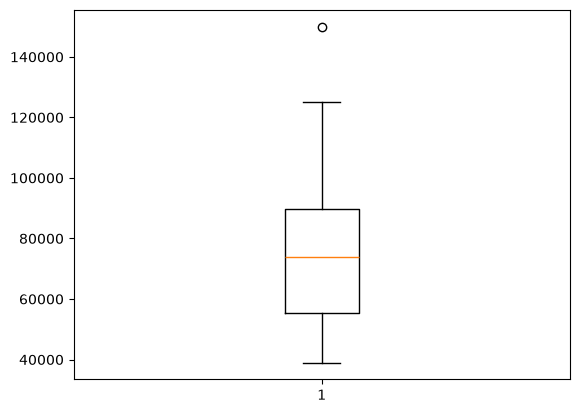

In [20]:
plt.boxplot(df['Salary'])

Q24. Create a Line Chart showing Monthly Watch Time of employees.

Q25. Plot Monthly Sales vs Experience.

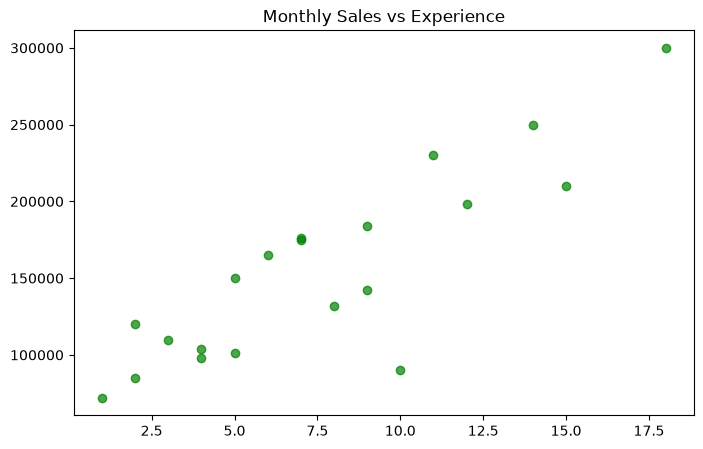

In [21]:
# Q25. Plot Monthly Sales vs Experience.
plt.figure(figsize=(8, 5))
plt.scatter(df['Experience'], df['Monthly_Sales'], color='green', alpha=0.7)
plt.title('Monthly Sales vs Experience')

plt.show()


A scatter plot is used because you are comparing two numeric variables:

Experience on the x-axis
Monthly Sales on the y-axis
It helps you see:

whether sales increase as experience increases
whether there is a pattern or relationship
whether points are spread out or clustered

# Part E – Correlation & Relationships (26–30)

Q26. Find correlation between Salary and Experience.

In [22]:
df['Salary'].corr(df['Experience'])


np.float64(0.9895015029940261)

Q27. Find correlation between Salary and Monthly Sales.

In [23]:
df['Salary'].corr(df['Monthly_Sales'])

np.float64(0.9016652628919205)

Q28. Find correlation between Training Hours and Performance Rating.

In [24]:
df['Training_Hours'].corr(df['Performance_Rating'])

np.float64(0.8813202962952855)

Q29. Interpret the strongest positive correlation.

<Axes: >

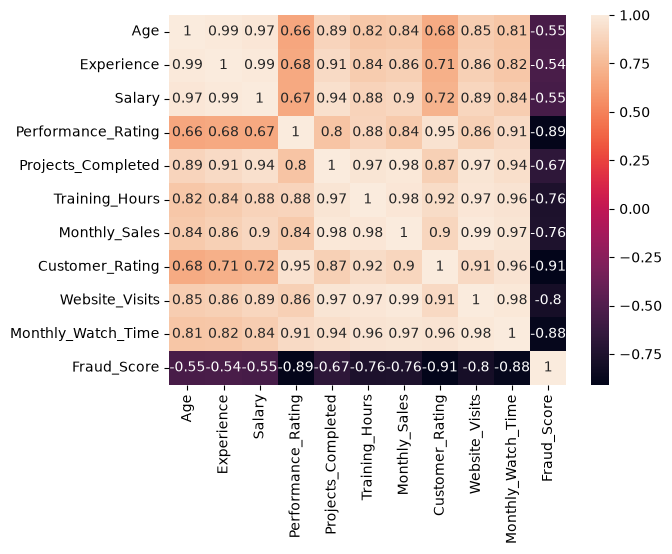

In [25]:
correlation_matrix = df.corr(numeric_only=True)
correlation_matrix
! pip install seaborn
import seaborn as sns


sns.heatmap(correlation_matrix,annot=True)

Q30. Which variables are negatively correlated (if any)?

In [26]:
correlation_matrix = df.corr(numeric_only=True)
negative_corr = correlation_matrix[correlation_matrix < 0]
print(negative_corr)

                        Age  Experience    Salary  Performance_Rating  \
Age                     NaN         NaN       NaN                 NaN   
Experience              NaN         NaN       NaN                 NaN   
Salary                  NaN         NaN       NaN                 NaN   
Performance_Rating      NaN         NaN       NaN                 NaN   
Projects_Completed      NaN         NaN       NaN                 NaN   
Training_Hours          NaN         NaN       NaN                 NaN   
Monthly_Sales           NaN         NaN       NaN                 NaN   
Customer_Rating         NaN         NaN       NaN                 NaN   
Website_Visits          NaN         NaN       NaN                 NaN   
Monthly_Watch_Time      NaN         NaN       NaN                 NaN   
Fraud_Score        -0.54692   -0.536798 -0.550976           -0.893701   

                    Projects_Completed  Training_Hours  Monthly_Sales  \
Age                                NaN            

# Part F – Sampling (31–34)

Q31. Take a random sample of 8 employees.

In [40]:
import numpy as np
import random

l = df['Employee_ID']
employees = np.array(l.values) 

print(employees)
print('Random samples of employees ID')
print(random.sample(list(employees), k = 10))

['E001' 'E002' 'E003' 'E004' 'E005' 'E006' 'E007' 'E008' 'E009' 'E010'
 'E011' 'E012' 'E013' 'E014' 'E015' 'E016' 'E017' 'E018' 'E019' 'E020']
['E019', 'E003', 'E008', 'E007', 'E011', 'E017', 'E013', 'E014', 'E001', 'E010']


Q32. Perform stratified sampling based on Department.

In [47]:
# Q32. Perform stratified sampling based on Department.
# Stratified sampling: divide population into strata (departments) and sample from each

from sklearn.model_selection import train_test_split

# Perform stratified split - select 50% of data, stratified by Department
stratified_sample, _ = train_test_split(
    df, 
    test_size=0.5, 
    stratify=df['Department'],
    random_state=42
)

print("Stratified Sample (50% of data, stratified by Department):")
print(f"Total sampled: {len(stratified_sample)} employees")
print(f"\nSample breakdown by Department:")
print(stratified_sample['Department'].value_counts().sort_index())
print("\nOriginal distribution by Department:")
print(df['Department'].value_counts().sort_index())
print("\nStratified sample details:")
print(stratified_sample[['Employee_ID', 'Department', 'Salary', 'Age', 'Experience']])


Stratified Sample (50% of data, stratified by Department):
Total sampled: 10 employees

Sample breakdown by Department:
Department
AI         3
Finance    2
HR         2
Testing    3
Name: count, dtype: int64

Original distribution by Department:
Department
AI         6
Finance    5
HR         4
Testing    5
Name: count, dtype: int64

Stratified sample details:
   Employee_ID Department  Salary  Age  Experience
0         E001         AI   45000   24           2
7         E008    Testing   39000   23           1
1         E002         HR   58000   29           5
13        E014    Finance   79000   32           7
4         E005         AI   72000   31           7
6         E007    Finance  120000   41          15
5         E006         HR   54000   27           4
19        E020         AI  150000   45          18
3         E004    Testing   50000   26           3
18        E019    Testing   56000   29           4


Q33. Perform cluster sampling using one department.

In [48]:
# Q34. Perform systematic sampling by selecting every 3rd employee.
# Systematic sampling: select every kth element from a population

# Set interval k = 3
k = 3

# Generate a random starting point (0, 1, or 2)
random.seed(42)
start = random.randint(0, k-1)

# Select every 3rd employee starting from the random start point
systematic_sample = df.iloc[start::k].reset_index(drop=True)

print("Systematic Sampling (every 3rd employee):")
print(f"Starting position: {start}")
print(f"Sampling interval: {k}")
print(f"Total sampled: {len(systematic_sample)} employees")
print("\nSystematic sample details:")
print(systematic_sample[['Employee_ID', 'Department', 'Salary', 'Age', 'Experience']])
print("\nIndex positions selected:", list(range(start, len(df), k)))


Systematic Sampling (every 3rd employee):
Starting position: 2
Sampling interval: 3
Total sampled: 6 employees

Systematic sample details:
  Employee_ID Department  Salary  Age  Experience
0        E003    Finance   85000   35          10
1        E006         HR   54000   27           4
2        E009         AI   68000   30           6
3        E012    Testing   61000   28           5
4        E015    Testing   43000   25           2
5        E018    Finance   87000   34           9

Index positions selected: [2, 5, 8, 11, 14, 17]


# Part G – Probability & Business Analytics (35–40)

Q35. Calculate the probability that an employee has left the company.

In [49]:
df.head()

,Employee_ID,Department,Gender,Age,Experience,Salary,Performance_Rating,Projects_Completed,Training_Hours,Monthly_Sales,Customer_Rating,Work_Mode,Left_Company,Email_Type,Sentiment,Website_Visits,Converted,Monthly_Watch_Time,Fraud_Score
0,E001,AI,Male,24,2,45000,4,5,18,120000,4.6,Hybrid,No,Spam,Positive,120,Yes,42,0.10
1,E002,HR,Female,29,5,58000,5,7,25,150000,4.8,Office,No,Not Spam,Positive,180,Yes,48,0.05
2,E003,Finance,Male,35,10,85000,3,6,12,90000,4.1,Office,Yes,Spam,Negative,95,No,30,0.80
3,E004,Testing,Female,26,3,50000,4,4,15,110000,4.3,Remote,No,Not Spam,Neutral,140,Yes,39,0.12
4,E005,AI,Male,31,7,72000,5,9,30,175000,4.9,Hybrid,No,Spam,Positive,220,Yes,55,0.07


In [61]:
left = df['Left_Company']=='Yes'
l = list(left.values)
sample = len(l)
count_left_comp = l.count(True)

prob_left_company = count_left_comp/sample

print(prob_left_company)



0.3


Q36. Calculate the probability that an employee belongs to the AI department.

In [66]:
left = df['Department']=='AI'
l = list(left.values)
print(l)
sample = len(l)
count_AI_department = l.count(True)

prob_AI_department =  count_AI_department/sample
print(sample , count_AI_department , prob_AI_department)

[np.True_, np.False_, np.False_, np.False_, np.True_, np.False_, np.False_, np.False_, np.True_, np.False_, np.False_, np.False_, np.True_, np.False_, np.False_, np.True_, np.False_, np.False_, np.False_, np.True_]
20 6 0.3


Q37. Calculate the conditional probability: P(Left Company | Performance Rating )

In [ ]:

# Step 1: Group by Performance_Rating and count total
total_by_rating = df.groupby('Performance_Rating').size()
print("Step 1: Total count by Performance Rating")
print(total_by_rating)
print()

# Step 2: Group by Performance_Rating and Left_Company = 'Yes' 
left_by_rating = df[df['Left_Company'] == 'Yes'].groupby('Performance_Rating').size()
print("Step 2: Count of employees who LEFT by Performance Rating")
print(left_by_rating)
print()

# Step 3: Calculate conditional probability by dividing
print("Step 3: Conditional Probability P(Left Company | Performance Rating)")
print("-" * 60)
cond_prob_simple = left_by_rating / total_by_rating
print(cond_prob_simple)
print()

# Show it in a nice format
print("\nFormatted Results:")
print("-" * 60)
for rating in sorted(df['Performance_Rating'].unique()):
    total = total_by_rating[rating]
    left = left_by_rating.get(rating, 0)
    prob = left / total
    print(f"Rating {rating}: Left={left}, Total={total}, P(Left|Rating={rating})={prob:.2%}")


Step 1: Total count by Performance Rating
Performance_Rating
2    1
3    5
4    7
5    7
dtype: int64

Step 2: Count of employees who LEFT by Performance Rating
Performance_Rating
2    1
3    5
dtype: int64

Step 3: Conditional Probability P(Left Company | Performance Rating)
------------------------------------------------------------
Performance_Rating
2    1.0
3    1.0
4    NaN
5    NaN
dtype: float64


Formatted Results:
------------------------------------------------------------
Rating 2: Left=1, Total=1, P(Left|Rating=2)=100.00%
Rating 3: Left=5, Total=5, P(Left|Rating=3)=100.00%
Rating 4: Left=0, Total=7, P(Left|Rating=4)=0.00%
Rating 5: Left=0, Total=7, P(Left|Rating=5)=0.00%


In [ ]:
P(Left Company | Performance Rating ) = p(left_company) ^ p()

Q38. Assume Website Visitors = Website_Visits and Converted = "Yes". Calculate
the overall Baseline Conversion Rate (BCR).

In [ ]:

# BCR = Count(Converted = 'Yes') / Total Website Visits
# Using groupby for counts

print("Q38: Baseline Conversion Rate (BCR) Calculation")
print("="*60)

# Step 1: Total website visitors
total_visitors = df['Website_Visits'].sum()
print(f"Step 1: Total Website Visits = {total_visitors}")

# Step 2: Count how many converted
converted_count = (df['Converted'] == 'Yes').sum()
print(f"Step 2: Count of Converted = 'Yes' = {converted_count}")

# Step 3: Calculate BCR
bcr = converted_count / total_visitors
print(f"\nStep 3: Baseline Conversion Rate (BCR)")
print(f"BCR = {converted_count} / {total_visitors} = {bcr:.4f}")
print(f"BCR (%) = {bcr * 100:.2f}%")

# Additional breakdown using groupby
print(f"\n\nBreakdown by Conversion Status:")
print("-"*60)
conversion_counts = df['Converted'].value_counts()
print(conversion_counts)
print(f"\nTotal employees: {len(df)}")
print(f"Converted: {conversion_counts.get('Yes', 0)} | Not Converted: {conversion_counts.get('No', 0)}")


Q38: Baseline Conversion Rate (BCR) Calculation
Step 1: Total Website Visits = 3698
Step 2: Count of Converted = 'Yes' = 14

Step 3: Baseline Conversion Rate (BCR)
BCR = 14 / 3698 = 0.0038
BCR (%) = 0.38%


Breakdown by Conversion Status:
------------------------------------------------------------
Converted
Yes    14
No      6
Name: count, dtype: int64

Total employees: 20
Converted: 14 | Not Converted: 6


In [77]:
df.head()

,Employee_ID,Department,Gender,Age,Experience,Salary,Performance_Rating,Projects_Completed,Training_Hours,Monthly_Sales,Customer_Rating,Work_Mode,Left_Company,Email_Type,Sentiment,Website_Visits,Converted,Monthly_Watch_Time,Fraud_Score
0,E001,AI,Male,24,2,45000,4,5,18,120000,4.6,Hybrid,No,Spam,Positive,120,Yes,42,0.10
1,E002,HR,Female,29,5,58000,5,7,25,150000,4.8,Office,No,Not Spam,Positive,180,Yes,48,0.05
2,E003,Finance,Male,35,10,85000,3,6,12,90000,4.1,Office,Yes,Spam,Negative,95,No,30,0.80
3,E004,Testing,Female,26,3,50000,4,4,15,110000,4.3,Remote,No,Not Spam,Neutral,140,Yes,39,0.12
4,E005,AI,Male,31,7,72000,5,9,30,175000,4.9,Hybrid,No,Spam,Positive,220,Yes,55,0.07


In [92]:
l = df.groupby('Converted').agg({'Website_Visits':'sum'})
print(l)

           Website_Visits
Converted                
No                    563
Yes                  3135


Q39. If the company expects a Minimum Detectable Effect (MDE) of 10%, calculate
the target conversion rate after improvement.

Q40. Perform an A/B Test on Monthly Watch Time: Group A = Work_Mode = Office,
Group B = Work_Mode = Hybrid. Calculate the mean watch time for both groups,
perform an Independent T-Test, interpret significance at α = 0.05, and conclude
whether the Hybrid work model results in significantly higher watch time.

# Part H – Advanced Statistical Challenges (41–50)

Q41. Calculate the 95% confidence interval for the population mean Salary and
interpret what it tells the company about pay estimates.

## Confidence Interval (CI) Formula

For a sample mean:

$$CI = \bar{x} \pm (Z \times SE)$$

or equivalently:

$$CI = \bar{x} \pm Z \times \frac{s}{\sqrt{n}}$$

### Where:

- $\bar{x}$ = Sample mean
- $s$ = Sample standard deviation
- $n$ = Sample size
- $Z$ = Critical value (1.96 for 95% confidence level)
- $SE = \frac{s}{\sqrt{n}}$ = Standard Error

### Interpretation:

The confidence interval provides a range of values that is likely to contain the true population parameter with a specified level of confidence (e.g., 95%).

Q42. Run an independent-samples t-test comparing Performance_Rating between
the AI and Finance departments. State the hypotheses and conclude at α = 0.05.

Q43. Compute Z-scores for Salary and flag any employees with |Z| > 2 as statistical
outliers.

Z=σX/μ​
Where:

X = observed value
μ = mean
σ = standard deviation

Q44. Perform a Chi-Square test of independence between Department and
Left_Company to check whether attrition is associated with department.

Q45. Perform a one-way ANOVA to test whether Monthly_Sales differs significantly
across the three Work_Mode categories (Office, Hybrid, Remote).

Q46. Fit a simple linear regression model predicting Salary from Experience. Report
the slope, intercept and R-squared, and interpret each in business terms.

Q47. Calculate Cohen's d to quantify the effect size of the difference in
Monthly_Watch_Time between the Office and Hybrid groups, and interpret the
magnitude.

Q48. Use bootstrapping (1,000 resamples) to estimate a 95% confidence interval for
the median Training_Hours.

Q49. Detect outliers in Monthly_Sales using the IQR method, remove them, and
compare the mean before and after removal.

Q50. Using Bayes' Theorem, calculate the posterior probability that an employee
has left the company given that their Performance_Rating is 3 or below AND their
Fraud_Score is above 0.5.